In [78]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/PHL_dataset.csv')

print(df.head())
df.info()

                  P_NAME   P_DETECTION P_DISCOVERY_FACILITY  P_YEAR  \
0  OGLE-2016-BLG-1227L b  Microlensing                 OGLE    2020   
1           Kepler-276 c       Transit               Kepler    2013   
2           Kepler-829 b       Transit               Kepler    2016   
3               K2-283 b       Transit                   K2    2018   
4           Kepler-477 b       Transit               Kepler    2016   

     P_UPDATE  P_MASS  P_MASS_ERROR_MIN  P_MASS_ERROR_MAX  P_MASS_LIMIT  \
0  2020-04-02  250.00            -120.0             413.0             0   
1  2018-09-25   16.60              -3.6               4.4             0   
2  2019-04-16    5.10               NaN               NaN             0   
3  2019-09-05   12.20               NaN               NaN             0   
4  2019-04-16    4.94               NaN               NaN             0   

      P_MASS_ORIGIN  ...  S_ABIO_ZONE  S_TIDAL_LOCK  P_HABZONE_OPT  \
0              Mass  ...          NaN      0.214133 

In [79]:
df.shape

(5599, 118)

In [80]:
df.describe()

,P_YEAR,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_RADIUS_LIMIT,P_PERIOD,...,S_HZ_CON0_MAX,S_HZ_CON1_MIN,S_HZ_CON1_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_HABITABLE,P_ESI
count,5599.000000,5592.000000,2506.000000,2506.000000,5599.000000,5592.000000,3847.000000,3847.000000,5599.000000,5.350000e+03,...,5366.000000,5366.000000,5366.000000,5366.000000,5.376000e+03,5595.000000,5599.000000,5599.000000,5599.000000,5358.000000
mean,2016.188962,442.521283,-127.777520,174.465166,0.022861,5.715494,-0.432279,0.544259,-0.000714,7.994082e+04,...,2.301153,1.239781,2.301153,3.596167,1.014471e+35,0.425790,0.047151,0.033577,0.019825,0.257089
std,4.527714,2369.505048,383.670428,625.151645,0.160982,5.331450,0.960669,1.568228,0.026721,5.498596e+06,...,4.587874,2.390133,4.587874,6.741964,5.259131e+36,0.077064,0.211981,0.180155,0.184617,0.131622
min,1992.000000,0.020000,-6038.739700,0.000000,-1.000000,0.310000,-32.506000,0.000000,-1.000000,9.070629e-02,...,0.001910,0.000911,0.001910,0.002434,4.356319e-05,0.029269,0.000000,0.000000,0.000000,0.023896
25%,2014.000000,4.040000,-73.100900,2.712500,0.000000,1.780000,-0.480000,0.130000,0.000000,4.465382e+00,...,1.060687,0.568834,1.060687,1.615711,4.781093e-01,0.391256,0.000000,0.000000,0.000000,0.186192
50%,2016.000000,8.750000,-19.069800,20.000000,0.000000,2.780000,-0.220000,0.280000,0.000000,1.156951e+01,...,1.561742,0.854147,1.561742,2.502441,1.361846e+00,0.443760,0.000000,0.000000,0.000000,0.268055
75%,2020.000000,162.092490,-2.542630,85.813670,0.000000,11.900000,-0.110000,0.581500,0.000000,4.150555e+01,...,2.364700,1.299225,2.364700,3.873593,2.556535e+00,0.470516,0.000000,0.000000,0.000000,0.301299
max,2024.000000,89700.000000,0.000000,12395.308000,1.000000,77.342000,0.000000,68.910000,0.000000,4.020000e+08,...,120.348830,67.331558,120.348830,214.468620,2.726899e+38,1.003328,1.000000,1.000000,2.000000,0.968362


In [81]:
df.columns

Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN',
       ...
       'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object', length=118)

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
cols_to_keep = [

    'P_HABITABLE',
    'P_ESI',
    'P_RADIUS',
    'P_MASS',
    'P_GRAVITY',
    'P_ESCAPE',
    'P_PERIOD',
    'P_SEMI_MAJOR_AXIS',
    'P_ECCENTRICITY',
    'P_INCLINATION',
    'P_TEMP_EQUIL',
    'P_TEMP_SURF',
    'P_TYPE_TEMP',

    'S_MASS',
    'S_RADIUS',
    'S_TEMPERATURE',
    'S_METALLICITY',
    'S_AGE',
    'S_MAG',
    'S_DISTANCE',
    'S_TYPE'
]


df = df[[col for col in cols_to_keep if col in df.columns]]

In [84]:
df.shape

(5599, 21)

Identify missing values

In [85]:
missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)

missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

print('Columns with Missing Values :')
print(missing_df.head(30))

Columns with Missing Values :
                   Missing Values  Percentage
S_TYPE                       3578   63.904269
P_TEMP_SURF                  3158   56.402929
P_INCLINATION                1311   23.414896
S_AGE                        1207   21.557421
P_ECCENTRICITY                777   13.877478
S_METALLICITY                 433    7.733524
P_PERIOD                      249    4.447223
P_ESI                         241    4.304340
P_TYPE_TEMP                   234    4.179318
P_TEMP_EQUIL                  234    4.179318
S_RADIUS                      232    4.143597
S_MAG                         219    3.911413
S_TEMPERATURE                 219    3.911413
S_DISTANCE                     21    0.375067
P_RADIUS                        7    0.125022
P_MASS                          7    0.125022
P_GRAVITY                       7    0.125022
P_ESCAPE                        7    0.125022
P_SEMI_MAJOR_AXIS               4    0.071441
S_MASS                          4    0.071441


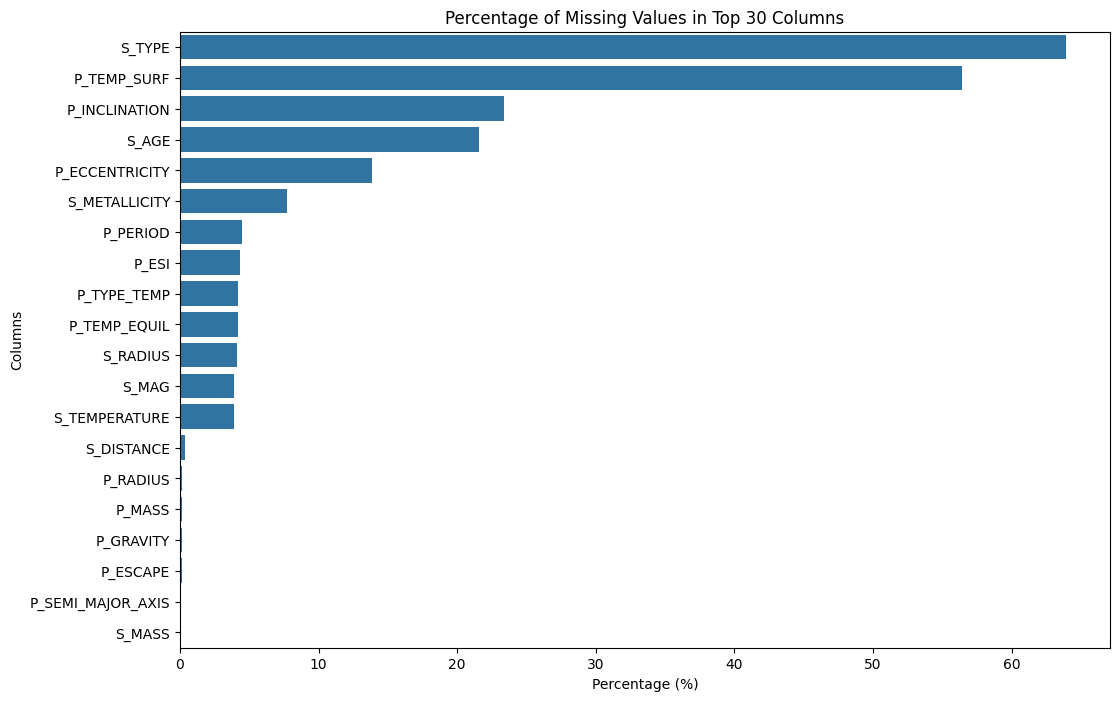

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=missing_df['Percentage'].head(30), y=missing_df.head(30).index)
plt.title('Percentage of Missing Values in Top 30 Columns')
plt.xlabel('Percentage (%)')
plt.ylabel('Columns')
plt.show()

In [87]:
df.isnull().sum()

,0
P_HABITABLE,0
P_ESI,241
P_RADIUS,7
P_MASS,7
P_GRAVITY,7
P_ESCAPE,7
P_PERIOD,249
P_SEMI_MAJOR_AXIS,4
P_ECCENTRICITY,777
P_INCLINATION,1311


In [88]:
df = df[df.isnull().mean(axis=1) < 0.5]


In [89]:
df.shape

(5391, 21)

In [90]:
numerical_cols = df.select_dtypes(include=['number']).columns

# Filter out numerical columns with more than 50% missing values
numerical_cols = [col for col in numerical_cols if missing_percentage.get(col, 0) <= 50]

print(f"Number of numerical columns: {len(numerical_cols)}")
print(f"Number of suitable numerical columns (<= 50% missing values): {len(numerical_cols)}")
print("Suitable numerical columns for outlier detection:")
print(numerical_cols)

Number of numerical columns: 18
Number of suitable numerical columns (<= 50% missing values): 18
Suitable numerical columns for outlier detection:
['P_HABITABLE', 'P_ESI', 'P_RADIUS', 'P_MASS', 'P_GRAVITY', 'P_ESCAPE', 'P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'P_ECCENTRICITY', 'P_INCLINATION', 'P_TEMP_EQUIL', 'S_MASS', 'S_RADIUS', 'S_TEMPERATURE', 'S_METALLICITY', 'S_AGE', 'S_MAG', 'S_DISTANCE']


In [91]:
import pandas as pd

# Apply one-hot encoding to 'P_TYPE_TEMP as it has 3 unique values'
df = pd.get_dummies(df, columns=['P_TYPE_TEMP'], prefix='P_TYPE_TEMP')

print("DataFrame after one-hot encoding 'P_TYPE_TEMP':")
df.head()
df.info()

DataFrame after one-hot encoding 'P_TYPE_TEMP':
<class 'pandas.core.frame.DataFrame'>
Index: 5391 entries, 1 to 5597
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   P_HABITABLE        5391 non-null   int64  
 1   P_ESI              5358 non-null   float64
 2   P_RADIUS           5384 non-null   float64
 3   P_MASS             5384 non-null   float64
 4   P_GRAVITY          5384 non-null   float64
 5   P_ESCAPE           5384 non-null   float64
 6   P_PERIOD           5341 non-null   float64
 7   P_SEMI_MAJOR_AXIS  5391 non-null   float64
 8   P_ECCENTRICITY     4821 non-null   float64
 9   P_INCLINATION      4287 non-null   float64
 10  P_TEMP_EQUIL       5365 non-null   float64
 11  P_TEMP_SURF        2441 non-null   float64
 12  S_MASS             5388 non-null   float64
 13  S_RADIUS           5366 non-null   float64
 14  S_TEMPERATURE      5375 non-null   float64
 15  S_METALLICITY      5166 non-n

In [92]:
outliers_data = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_data[col] = outliers

print("Outliers calculated for suitable numerical columns.")
print(f"Number of columns with identified outliers: {len([col for col, data in outliers_data.items() if not data.empty])}")

Outliers calculated for suitable numerical columns.
Number of columns with identified outliers: 18


In [93]:
for col, outliers in outliers_data.items():
    print(f"Column '{col}': {len(outliers)} outliers")

Column 'P_HABITABLE': 70 outliers
Column 'P_ESI': 291 outliers
Column 'P_RADIUS': 6 outliers
Column 'P_MASS': 965 outliers
Column 'P_GRAVITY': 1089 outliers
Column 'P_ESCAPE': 744 outliers
Column 'P_PERIOD': 938 outliers
Column 'P_SEMI_MAJOR_AXIS': 876 outliers
Column 'P_ECCENTRICITY': 579 outliers
Column 'P_INCLINATION': 438 outliers
Column 'P_TEMP_EQUIL': 86 outliers
Column 'S_MASS': 395 outliers
Column 'S_RADIUS': 364 outliers
Column 'S_TEMPERATURE': 269 outliers
Column 'S_METALLICITY': 201 outliers
Column 'S_AGE': 308 outliers
Column 'S_MAG': 55 outliers
Column 'S_DISTANCE': 87 outliers


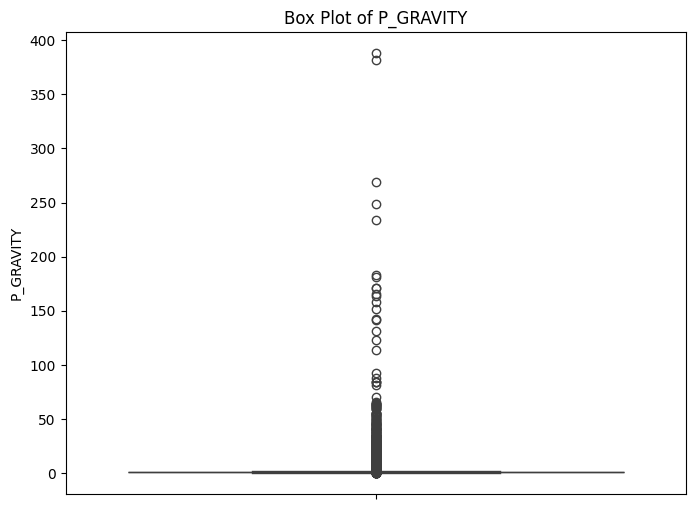

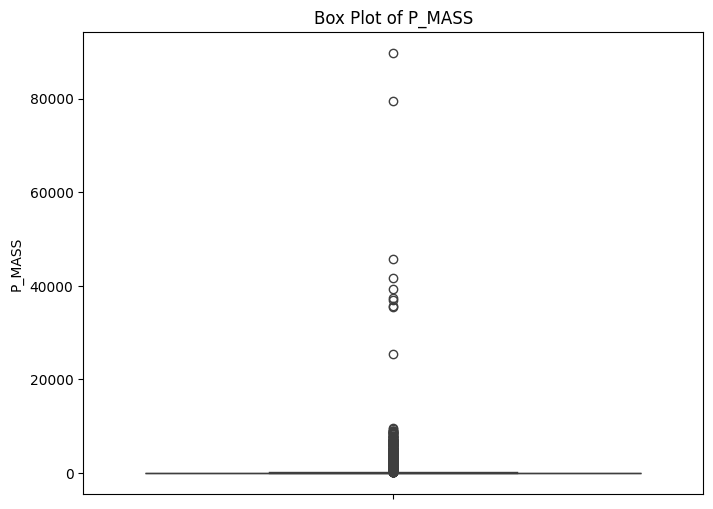

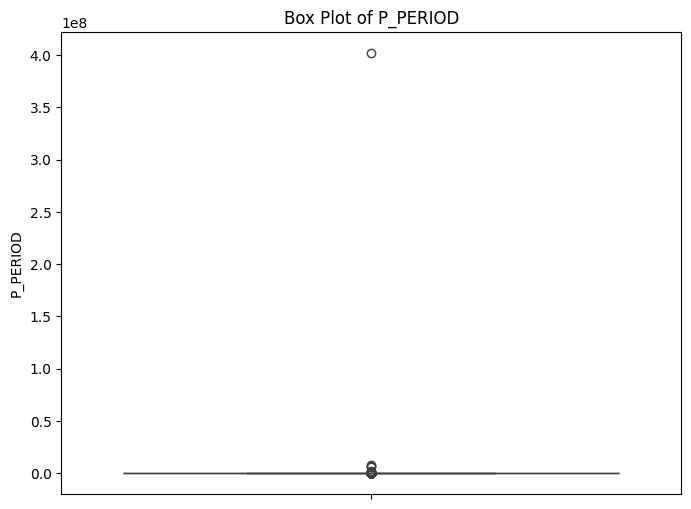

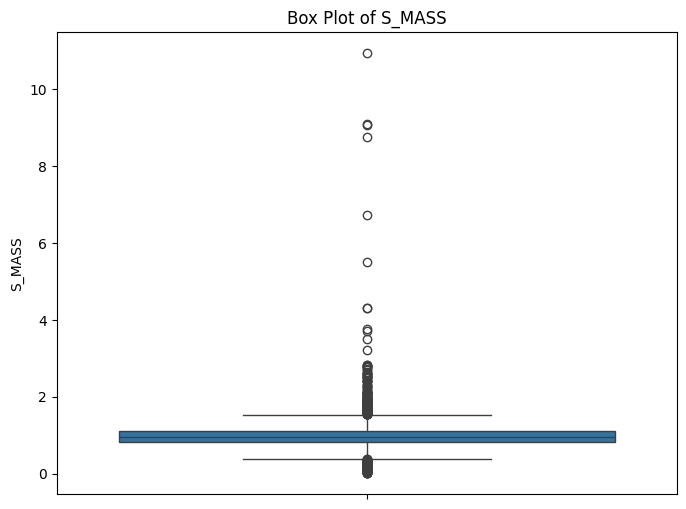

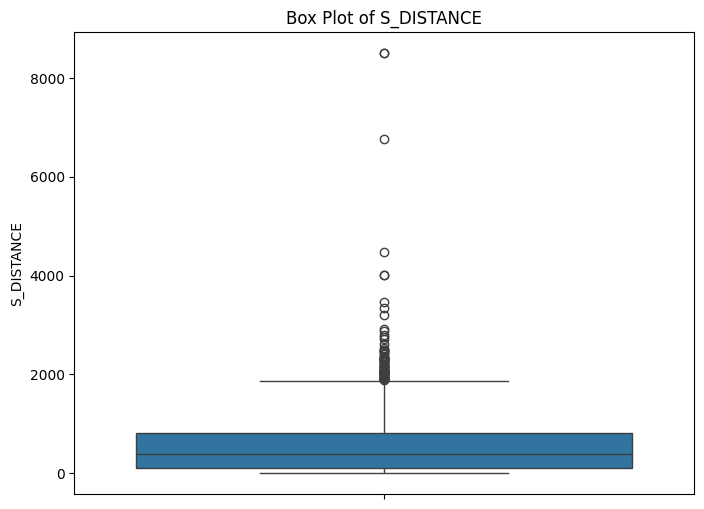

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Based on the previous outlier detection, these columns show significant outliers
key_numerical_cols = [ 'P_GRAVITY', 'P_MASS', 'P_PERIOD', 'S_MASS',  'S_DISTANCE']

for col in key_numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


Imputing missing values

In [95]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object","bool"]).columns

# Numerical: Median Imputation
for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Categorical: Mode Imputation
for col in cat_cols:
    mode_value = df[col].mode()
    if not mode_value.empty:
        df[col] = df[col].fillna(mode_value[0])

print("Remaining missing values:\n")
print(df.isnull().sum())

Remaining missing values:

P_HABITABLE          0
P_ESI                0
P_RADIUS             0
P_MASS               0
P_GRAVITY            0
P_ESCAPE             0
P_PERIOD             0
P_SEMI_MAJOR_AXIS    0
P_ECCENTRICITY       0
P_INCLINATION        0
P_TEMP_EQUIL         0
P_TEMP_SURF          0
S_MASS               0
S_RADIUS             0
S_TEMPERATURE        0
S_METALLICITY        0
S_AGE                0
S_MAG                0
S_DISTANCE           0
S_TYPE               0
P_TYPE_TEMP_Cold     0
P_TYPE_TEMP_Hot      0
P_TYPE_TEMP_Warm     0
dtype: int64


In [96]:
# IQR capping
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)



In [98]:
# # Log transform skewed features
# skewed_cols = df[num_cols].skew().abs()
# skewed_cols = skewed_cols[skewed_cols > 1].index

# df[skewed_cols] = np.log1p(df[skewed_cols])

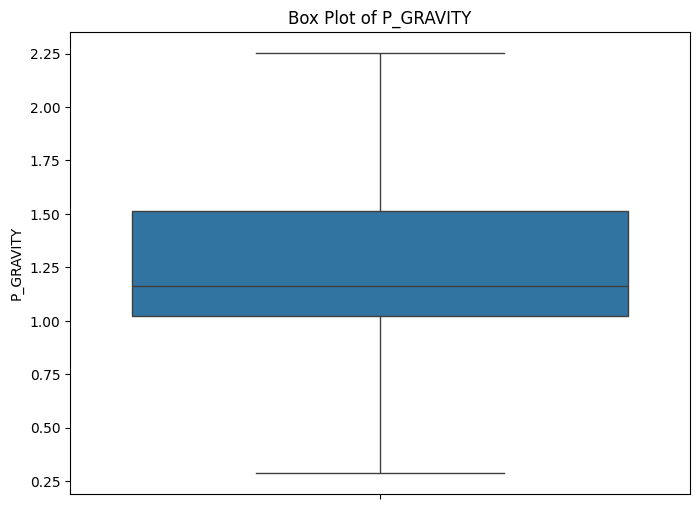

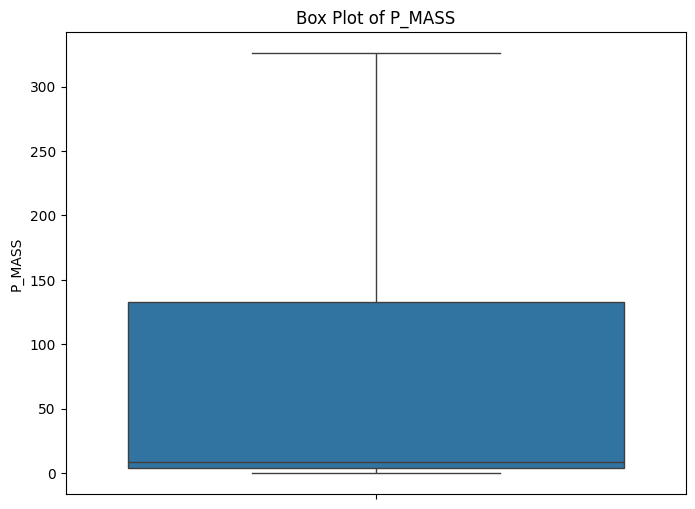

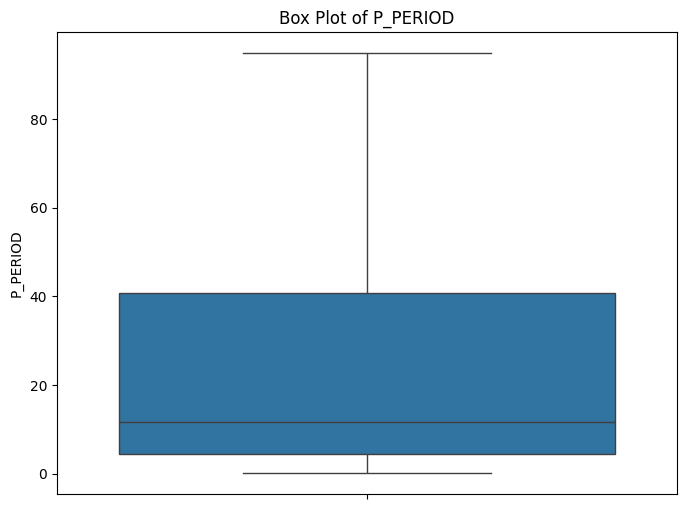

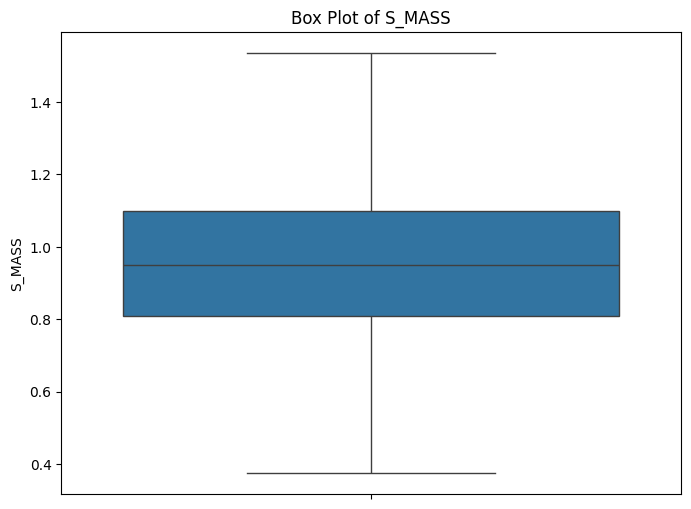

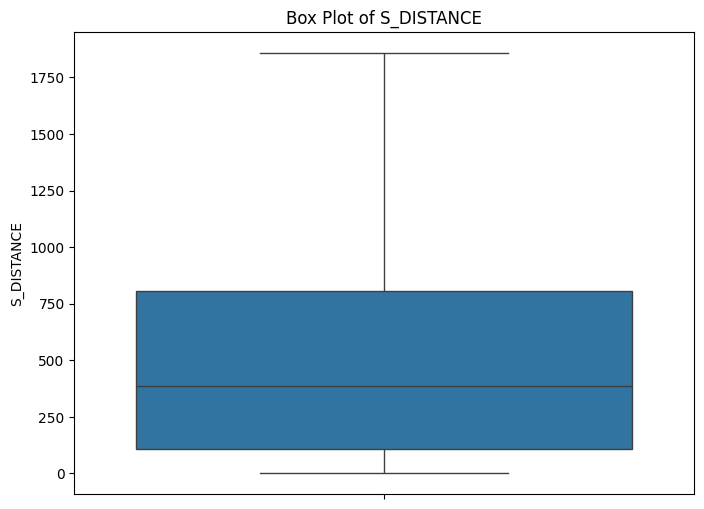

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Based on the previous outlier detection, these columns show significant outliers
key_numerical_cols = [ 'P_GRAVITY', 'P_MASS', 'P_PERIOD', 'S_MASS',  'S_DISTANCE']

for col in key_numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

In [100]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separate features and targets
target_cols = ["P_HABITABLE", "P_ESI"]
feature_cols = [col for col in df.columns if col not in target_cols ]

# Select numerical features only
num_cols = df[feature_cols].select_dtypes(include=["int64", "float64"]).columns

# Apply Standard Scaling
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])



In [101]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr()

,P_HABITABLE,P_ESI,P_RADIUS,P_MASS,P_GRAVITY,P_ESCAPE,P_PERIOD,P_SEMI_MAJOR_AXIS,P_ECCENTRICITY,P_INCLINATION,P_TEMP_EQUIL,P_TEMP_SURF,S_MASS,S_RADIUS,S_TEMPERATURE,S_METALLICITY,S_AGE,S_MAG,S_DISTANCE
P_HABITABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P_ESI,NaN,1.000000,-0.664092,-0.568583,-0.216018,-0.535328,0.138846,0.065030,-0.160396,0.270447,-0.402119,NaN,-0.441635,-0.444449,-0.325100,-0.204300,0.039858,0.263377,0.006443
P_RADIUS,NaN,-0.664092,1.000000,0.895610,0.404354,0.838062,0.379737,0.429896,0.456008,-0.147488,-0.016322,NaN,0.403399,0.461362,0.175357,0.190082,-0.024961,-0.499601,-0.264516
P_MASS,NaN,-0.568583,0.895610,1.000000,0.693570,0.965031,0.422629,0.476657,0.484105,-0.144513,-0.071145,NaN,0.382060,0.435151,0.122323,0.167734,-0.049143,-0.513001,-0.291476
P_GRAVITY,NaN,-0.216018,0.404354,0.693570,1.000000,0.782397,0.289471,0.332718,0.335879,-0.092574,-0.104774,NaN,0.202706,0.229038,0.010298,0.072808,-0.066554,-0.348861,-0.238971
P_ESCAPE,NaN,-0.535328,0.838062,0.965031,0.782397,1.000000,0.450504,0.506118,0.491216,-0.106691,-0.128682,NaN,0.363880,0.415600,0.110622,0.169997,-0.057645,-0.505009,-0.281297
P_PERIOD,NaN,0.138846,0.379737,0.422629,0.289471,0.450504,1.000000,0.963068,0.458854,0.217812,-0.653030,NaN,0.197182,0.252384,0.016809,-0.010121,0.022692,-0.448407,-0.170693
P_SEMI_MAJOR_AXIS,NaN,0.065030,0.429896,0.476657,0.332718,0.506118,0.963068,1.000000,0.451555,0.209492,-0.668610,NaN,0.240577,0.301313,0.052844,0.001862,-0.021834,-0.471787,-0.172020
P_ECCENTRICITY,NaN,-0.160396,0.456008,0.484105,0.335879,0.491216,0.458854,0.451555,1.000000,0.020809,-0.297113,NaN,0.111205,0.186101,-0.080799,0.073180,0.082562,-0.592244,-0.433644
P_INCLINATION,NaN,0.270447,-0.147488,-0.144513,-0.092574,-0.106691,0.217812,0.209492,0.020809,1.000000,-0.369726,NaN,-0.125881,-0.130069,-0.131168,-0.085062,-0.021462,0.039915,-0.015699


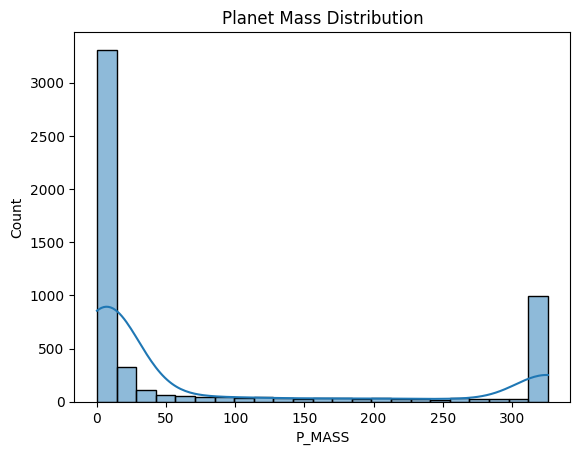

In [99]:
sns.histplot(df['P_MASS'], kde=True)
plt.title("Planet Mass Distribution")
plt.show()
